# Installing necessary libraries

In [17]:
!pip install pandas numpy scikit-learn nltk
!pip install transformers

# Importing Libraries

In [36]:
import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [6]:
df = pd.read_csv(
    "IMDB Dataset.csv",
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip'  # Some rows caused parsing errors due to irregular formatting. These were handled using on_bad_lines='skip'.
)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Check Data

In [7]:
print(df.shape)
print(df.isnull().sum())
df['sentiment'].value_counts()

(10273, 2)
review       0
sentiment    0
dtype: int64


,count
sentiment,
positive,5153
negative,5120


## Clean Text

In [8]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # keep alphabets only
    text = text.lower()
    text = text.strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)

## Remove Stopwords

In [10]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])
df['clean_review'] = df['clean_review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Convert labels to numeric form

In [11]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [12]:
df = df[['clean_review', 'label']]
df.head()

,clean_review,label
0,one reviewers mentioned watching oz episode ho...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake thinks zombie...,0
4,petter mattei love time money visually stunnin...,1


# Split Dataset (70 / 15 / 15)
### Train + Temp split
### Validation + Test split

In [15]:
X = df['clean_review']
y = df['label']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [16]:
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 7191
Validation size: 1541
Test size: 1541


## Why we used stratify=y ?
### Ans) To keep same ratio of positive/negative reviews in all splits

# Tokenization (BERT Tokenizer)

In [19]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
train_encodings = tokenize_data(X_train)
val_encodings = tokenize_data(X_val)
test_encodings = tokenize_data(X_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [20]:
print(train_encodings.keys())

KeysView({'input_ids': tensor([[  101, 24761, 10230,  ...,     0,     0,     0],
        [  101,  5777,  2720,  ...,     0,     0,     0],
        [  101,  3185, 10381,  ...,  2730, 10381,   102],
        ...,
        [  101, 12524,  3185,  ...,     0,     0,     0],
        [  101,  5409,  4516,  ...,     0,     0,     0],
        [  101,  8639,  9457,  ..., 13526,  3336,   102]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]])})


# Dataset + DataLoader (Using PyTorch)

### Create Custom Dataset Class

In [23]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

### Create Dataset Objects

In [24]:
train_dataset = IMDbDataset(train_encodings, y_train)
val_dataset = IMDbDataset(val_encodings, y_val)
test_dataset = IMDbDataset(test_encodings, y_test)

### Create DataLoaders

In [26]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [27]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


# BERT Model + Fine-Tuning

### Load Pre-trained BERT Model

In [30]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [33]:
optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch} Loss: {total_loss/len(train_loader)}")

Epoch 0: 100%|██████████| 450/450 [02:58<00:00,  2.52it/s, loss=0.355]


Epoch 0 Loss: 0.4060314607868592


Epoch 1: 100%|██████████| 450/450 [03:06<00:00,  2.42it/s, loss=0.169]

Epoch 1 Loss: 0.2127832825668156


In [35]:
model.eval()
preds = []
true_labels = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

acc = accuracy_score(true_labels, preds)
print("Validation Accuracy:", acc)

Validation Accuracy: 0.872160934458144


# Evaluation

In [37]:
model.eval()
preds = []
true_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [38]:
accuracy = accuracy_score(true_labels, preds)
precision = precision_score(true_labels, preds)
recall = recall_score(true_labels, preds)
f1 = f1_score(true_labels, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8663205710577547
Precision: 0.8370986920332937
Recall: 0.9107373868046572
F1 Score: 0.872366790582404


In [39]:
cm = confusion_matrix(true_labels, preds)
print(cm)

[[631 137]
 [ 69 704]]


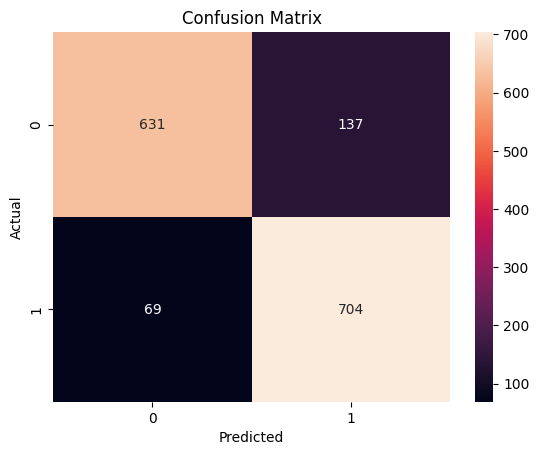

In [40]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       768
           1       0.84      0.91      0.87       773

    accuracy                           0.87      1541
   macro avg       0.87      0.87      0.87      1541
weighted avg       0.87      0.87      0.87      1541



# Model Performance Analysis
### The fine-tuned BERT model achieved an overall accuracy of 87%, indicating strong performance in classifying movie reviews into positive and negative sentiments.

## Class-wise Performance
### Class 0 (Negative Reviews):
Precision: 0.90
Recall: 0.82
F1-score: 0.86
### Class 1 (Positive Reviews):
Precision: 0.84
Recall: 0.91
F1-score: 0.87

This shows that the model is very precise in predicting negative reviews (fewer false positives).
It has high recall for positive reviews, meaning it correctly identifies most positive sentiments.

BERT’s contextual understanding helps capture semantic meaning of text, improving classification performance.
The model handles both classes well, with slightly better detection of positive sentiment.
The relatively low number of misclassifications shows effective fine-tuning.